In [2]:
import pandas as pd

df = pd.read_csv("../data/heart_cleveland.csv")
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (302, 14)


,63.0,1.0,1.0.1,145.0,233.0,1.0.2,2.0,150.0,0.0,2.3,3.0,0.0.1,6.0,0
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


In [3]:
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]
df = pd.read_csv("../data/heart_cleveland.csv", header=None, names=columns)
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Target counts (0 = no disease, 1–4 = disease present in original coding):")
print(df["target"].value_counts().sort_index())


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target counts (0 = no disease, 1–4 = disease present in original coding):
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [5]:
# 0 = lower risk (no disease), 1 = higher risk (any disease)
df["risk"] = (df["target"] > 0).astype(int)
print(df["risk"].value_counts())
df[["age", "chol", "target", "risk"]].head()

risk
0    164
1    139
Name: count, dtype: int64


,age,chol,target,risk
0,63.0,233.0,0,0
1,67.0,286.0,2,1
2,67.0,229.0,1,1
3,37.0,250.0,0,0
4,41.0,204.0,0,0


Matplotlib is building the font cache; this may take a moment.


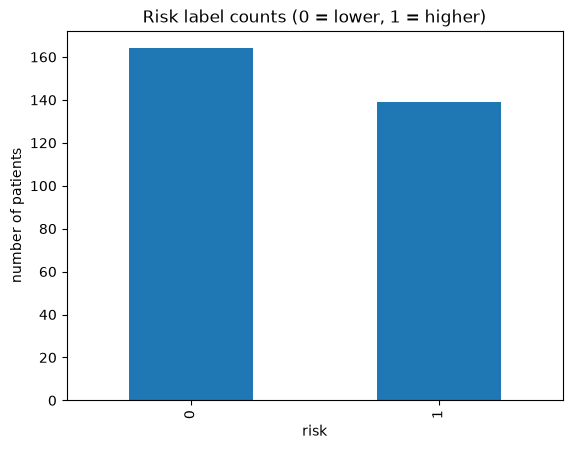

In [6]:
import matplotlib.pyplot as plt

df["risk"].value_counts().sort_index().plot(kind="bar")
plt.title("Risk label counts (0 = lower, 1 = higher)")
plt.xlabel("risk")
plt.ylabel("number of patients")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

# Treat '?' as missing, then force columns to numbers
df_clean = df.replace("?", np.nan).copy()
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Drop rows that still have missing values after that
df_clean = df_clean.dropna()
print("Rows after cleaning:", len(df_clean))

feature_cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
                "thalach", "exang", "oldpeak", "slope", "ca", "thal"]
X = df_clean[feature_cols]
y = df_clean["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Rows after cleaning: 297
Accuracy on test set: 0.8333333333333334
Confusion matrix:
[[28  4]
 [ 6 22]]
